<a href="https://colab.research.google.com/github/alangilsanchez/MineriaDeDatos/blob/main/PorcentajeDeColores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice (1).csv


In [2]:
import pandas as pd
df = pd.read_csv('munsell-array-fixed-choice.csv')
df #display the dataframe

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)
...,...,...,...,...,...,...,...,...,...,...
75,H19,19,1,5RP2/8,#591340,purple,purple,purple,morado (purple),itsidyeisi (purple)
76,A20,20,8,10RP9/2,#efdfe0,pink,white,white,blanco (white),jaibas (white)
77,C20,20,6,10RP7/8,#ea95a0,pink,pink,red,rosada (pink),jainas (red)
78,E20,20,4,10RP5/14,#d73f6a,pink,pink,red,rosada (pink),jainas (red)


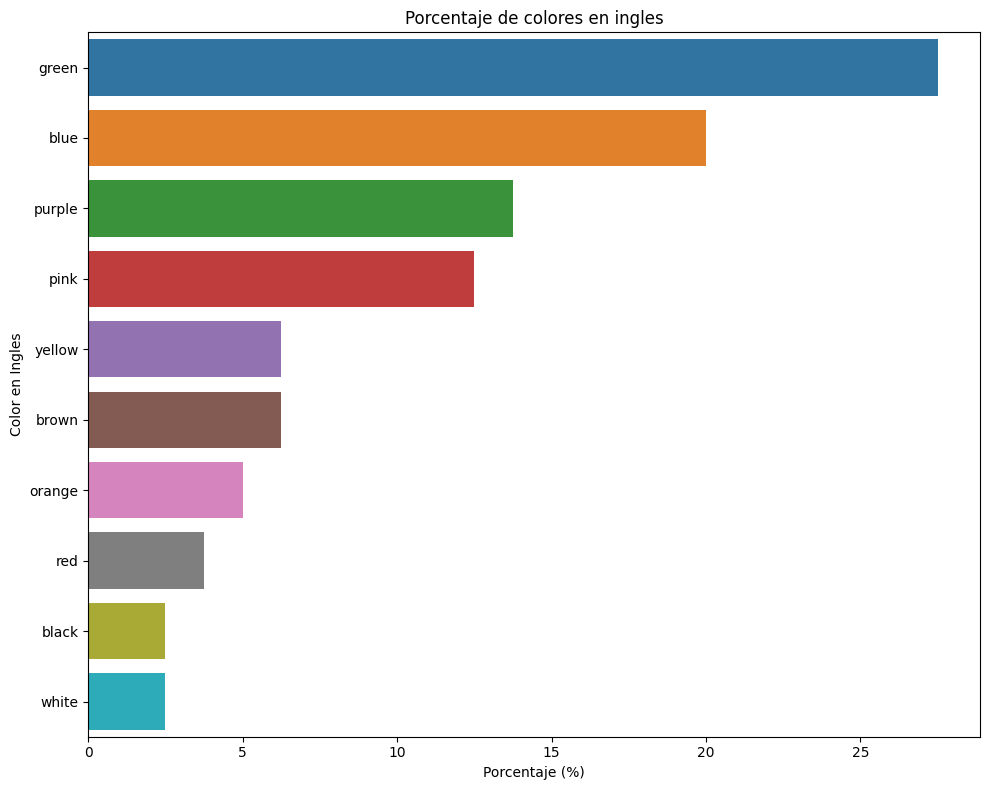

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage de cada color en Ingles
english_color_percentages = df['english_color'].value_counts(normalize=True) * 100

# Ordena los porcentajes para una mejor visualización
english_color_percentages = english_color_percentages.sort_values(ascending=False)

# Crea el grafico
plt.figure(figsize=(10, 8))
sns.barplot(x=english_color_percentages.values, y=english_color_percentages.index, hue=english_color_percentages.index, legend=False)
plt.title('Porcentaje de colores en ingles')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Color en Ingles')
plt.tight_layout()
plt.show()

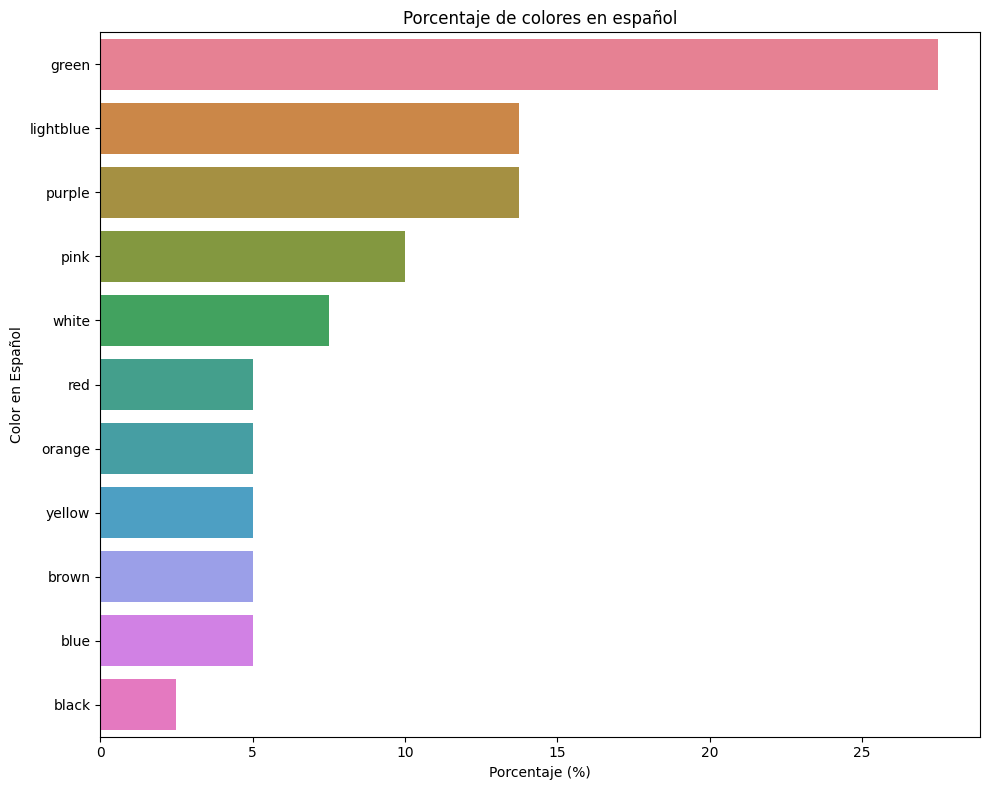

In [10]:
spanish_color_percentages = df['spanish_color'].value_counts(normalize=True) * 100

# Ordena los porcentajes para una mejor visualización
spanish_color_percentages = spanish_color_percentages.sort_values(ascending=False)

# Crea el grafico
plt.figure(figsize=(10, 8))
sns.barplot(x=spanish_color_percentages.values, y=spanish_color_percentages.index, hue=spanish_color_percentages.index, legend=False)
plt.title('Porcentaje de colores en español')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Color en Español')
plt.tight_layout()
plt.show()

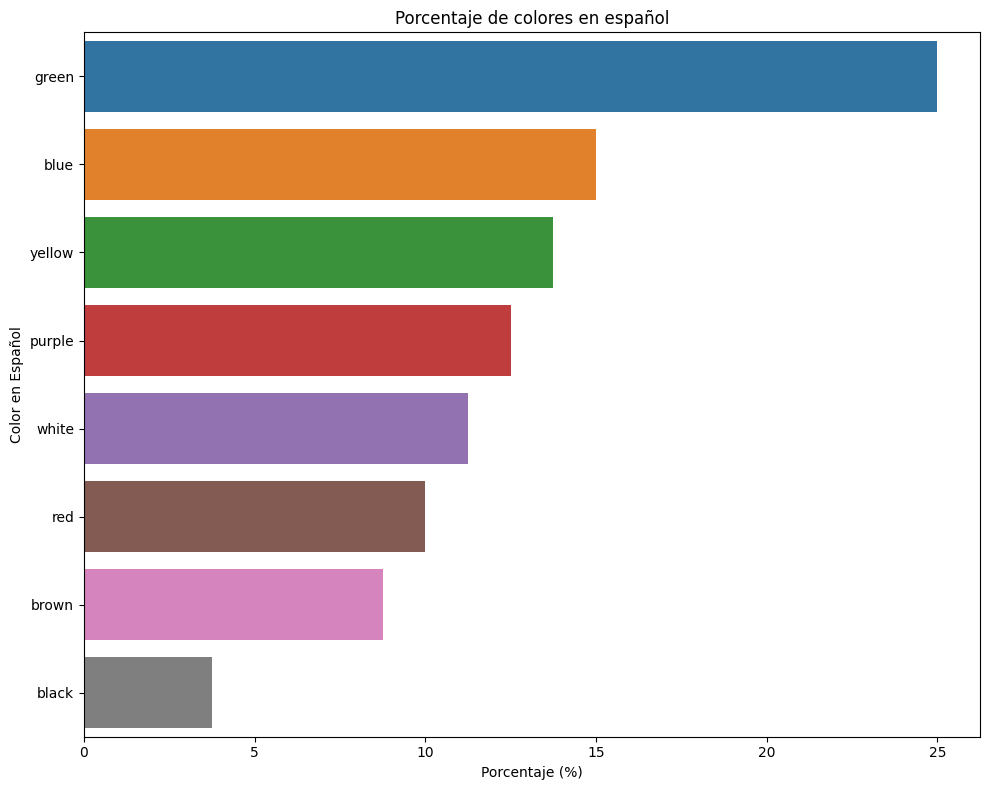

In [11]:
tsimane_color_percentages = df['tsimane_color'].value_counts(normalize=True) * 100

# Ordena los porcentajes para una mejor visualización
tsimane_color_percentages = tsimane_color_percentages.sort_values(ascending=False)

# Crea el grafico
plt.figure(figsize=(10, 8))
sns.barplot(x=tsimane_color_percentages.values, y=tsimane_color_percentages.index, hue=tsimane_color_percentages.index, legend=False)
plt.title('Porcentaje de colores en español')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Color en Español')
plt.tight_layout()
plt.show()

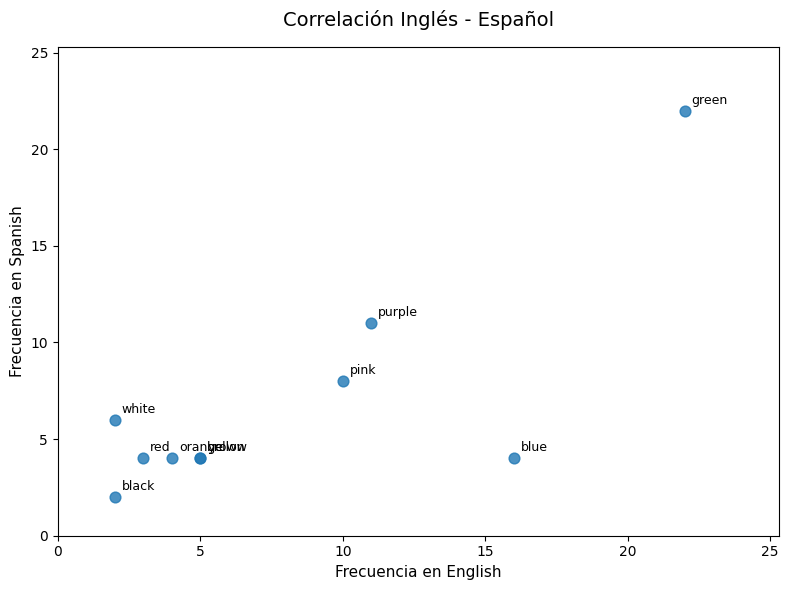

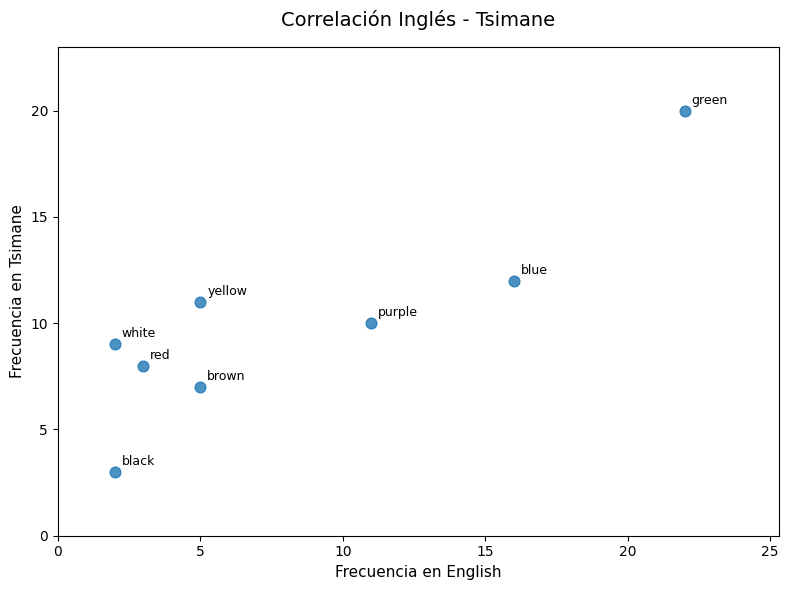

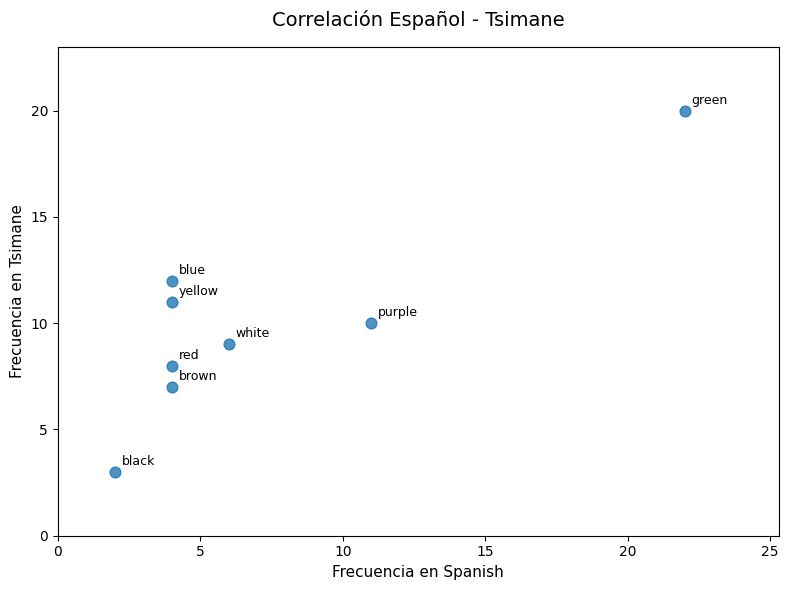

In [22]:
# Creamos DataFrames de frecuencias para cada idioma
english_df = df['english_color'].value_counts().reset_index()
english_df.columns = ['color', 'count_en']

spanish_df = df['spanish_color'].value_counts().reset_index()
spanish_df.columns = ['color', 'count_es']

tsimane_df = df['tsimane_color'].value_counts().reset_index()
tsimane_df.columns = ['color', 'count_ts']

# 2. Definición de los pares de correlación
# Usamos 'inner' join para asegurar que solo graficamos colores que existen en ambos idiomas del par
pares = [
    {'name': 'Inglés - Español', 'df1': english_df, 'df2': spanish_df, 'col1': 'count_en', 'col2': 'count_es', 'lab1': 'English', 'lab2': 'Spanish'},
    {'name': 'Inglés - Tsimane', 'df1': english_df, 'df2': tsimane_df, 'col1': 'count_en', 'col2': 'count_ts', 'lab1': 'English', 'lab2': 'Tsimane'},
    {'name': 'Español - Tsimane', 'df1': spanish_df, 'df2': tsimane_df, 'col1': 'count_es', 'col2': 'count_ts', 'lab1': 'Spanish', 'lab2': 'Tsimane'}
]


for par in pares:
    # Unir los datos por la columna 'color'
    merged = pd.merge(par['df1'], par['df2'], on='color', how='inner')

    # Crear la figura
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

    # Graficar puntos
    ax.scatter(merged[par['col1']], merged[par['col2']], s=60, color='tab:blue', alpha=0.8)


    for i, row in merged.iterrows():
        ax.annotate(
            row['color'],
            (row[par['col1']], row[par['col2']]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )


    ax.grid(False)
    ax.set_facecolor('white')
    ax.set_title(f"Correlación {par['name']}", fontsize=14, pad=15)
    ax.set_xlabel(f"Frecuencia en {par['lab1']}", fontsize=11)
    ax.set_ylabel(f"Frecuencia en {par['lab2']}", fontsize=11)

    # Ajuste de límites para dejar espacio a las etiquetas
    ax.set_xlim(left=0, right=merged[par['col1']].max() * 1.15)
    ax.set_ylim(bottom=0, top=merged[par['col2']].max() * 1.15)

    plt.tight_layout()
    plt.show()